In [1]:
import paicos as pa
import numpy as np
import cupy as cp
import turbocluster as tc
import math
from numba import cuda
import nvtx
import finufft
from IPython.display import Latex
import scipy.signal

pa.settings.strict_units = False
# A snapshot object
# snap = pa.Snapshot(pa.data_dir, 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom-simulations-new-ics/halo_0003/tng/zoom12_ics_v1/output', 247)
# snap = pa.Snapshot('/scratch/lperrone/zoom12_ics_v1/output', 247, basename='snap')
snap = pa.Snapshot('/llust21/cosmo-plasm/zoom-simulations-arepo2/halo_0003/tng/zoom12/output',
                   305, basename='snapshot')
center = snap.Cat.Group['GroupPos'][0]
widths = np.array([2e2, 2e2, 2e2], dtype=float) ## good for testing
# widths = np.array([2e1, 2e1, 2e1], dtype=float)





The default number of OpenMP threads, 8, exceeds the 1 available on your system. Setting numthreads=1. You can set numthreads with e.g. the command
 paicos.set_numthreads(16)




In [2]:
import cmasher as cmr
get_ipython().run_line_magic('matplotlib', 'widget')
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize

grays = plt.cm.gray(np.linspace(0,1,10))
reds = plt.cm.Reds_r(np.linspace(0,1,10))
blues = plt.cm.Blues_r(np.linspace(0,1,10))
greens = plt.cm.Greens_r(np.linspace(0,1,10))
oranges = plt.cm.Oranges_r(np.linspace(0,1,10))

# plt.rc('font', family='serif')
# plt.rcParams['font.serif'] = 'ITC Bookman'
plt.rcParams['font.size'] = 16
plt.rcParams['lines.linewidth'] = 1.7
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.labelsize']= 16
plt.rcParams['ytick.labelsize']= 16
plt.rcParams['xtick.minor.size']= 4.0
plt.rcParams['ytick.minor.size']= 4.0
plt.rcParams['xtick.major.size']= 5.0
plt.rcParams['ytick.major.size']= 5.0
plt.rcParams['xtick.minor.width']= 0.7
plt.rcParams['ytick.minor.width']= 0.7
plt.rcParams['xtick.major.width']= 1.
plt.rcParams['ytick.major.width']= 1.

plt.rcParams['xtick.direction']= 'in'
plt.rcParams['ytick.direction']= 'in'


In [3]:
density_unit = snap['0_Density'].unit

In [4]:
depo = tc.DepositCartesianGrid(snap, center, widths, npoints=64, 
                                   threadsperblock=256, 
                                   regionType='cartesian', kernel_type="PCS")



Attempting to get derived variable: 0_Volume...	[DONE]



In [5]:
# fixed seed for reproducibility
rng = np.random.default_rng(seed=456789)

Nx, Ny, Nz = 256, 256, 256
Lx, Ly, Lz = 8e2, 8e2, 8e2

kx = 2.0*np.pi*np.fft.fftfreq(Nx, d=Lx/Nx)
ky = 2.0*np.pi*np.fft.fftfreq(Ny, d=Ly/Ny)
kz = 2.0*np.pi*np.fft.rfftfreq(Nz, d=Lz/Nz)

KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')

K2 = KX**2 + KY**2 + KZ**2

phases_rho = 2.0*np.pi*rng.uniform(low=-1.0, high=1.0, size=(Nx,Ny,Nz//2+1))


In [6]:
def make_IC(test_type='kolmogorov',**kwargs):

    if (test_type=='kolmogorov'):
        power_law_exponent = -5./3.
        K2min = (2.0*np.pi/Lx)**2 + (2.0*np.pi/Ly)**2 + (2.0*np.pi/Lz)**2
        K2max = 100*K2min
        # energy per 3D mode \times k^2 = E(k) \sim k^power_law_exponent
        # ==> energy per 3D mode \sim k^[(power_law_exponent-2)/2]
        
        # For Kolmogorov spectrum
        ampl = np.zeros(K2.shape)
        ampl = np.where((K2>=K2min)*(K2<K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
        ampl = np.where((K2>K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.))*np.exp(-(K2-K2max)/K2max),ampl)
        
        
        
        hat_den = (Nx*Ny*Nz)*ampl*np.exp(1j*phases_rho)/(Lx*Ly*Lz)
        # hat_den = np.sqrt((Nx*Ny*Nz))*ampl*np.exp(1j*phases_rho)
        # hat_den = ampl*np.exp(1j*phases_rho)
        density_cartesian = np.fft.irfftn(hat_den)
        
        density_cartesian_cut = density_cartesian[10:10+64,15:15+64,22:22+64]*density_unit

    elif (test_type=='sin'):
        if "m_mode" not in kwargs:
            print('error: must choose a mode')
            return
        else:
            m_mode = kwargs["m_mode"]
        
        # simple sinusoidal
        ampl = np.zeros(K2.shape)
        ampl = np.where((KX==m_mode*2.*np.pi/Lx)*(KY==0.0)*(KZ==0.0),1.0,0.0)
        
        hat_den = (Nx*Ny*Nz)*ampl*np.exp(1j*phases_rho)/(Lx*Ly*Lz)
        # hat_den = np.sqrt((Nx*Ny*Nz))*ampl*np.exp(1j*phases_rho)
        # hat_den = ampl*np.exp(1j*phases_rho)
        density_cartesian = np.fft.irfftn(hat_den)
        
        density_cartesian_cut = density_cartesian[10:10+64,15:15+64,22:22+64]*density_unit

    elif (test_type=='snap'):
        
        density_cartesian_cut = depo.deposit_variable('0_Density', weight='0_Volume')

    return density_cartesian_cut

In [7]:
def compute_make_plot(test_type='kolmogorov',**kwargs):

    density_cartesian_cut = make_IC(test_type,**kwargs)
    
    powerspectr_basic, k1d_basic, (KX_basic, KY_basic, KZ_basic, hat_var_basic) = depo.power_spectrum1d(density_cartesian_cut)

    powerspectr_padded, k1d_padded, (KX_padded, KY_padded, KZ_padded, hat_var_padded) = depo.power_spectrum1d(density_cartesian_cut,
                                                              npads=6)

    powerspectr_hann, k1d_hann, (KX_hann, KY_hann, KZ_hann, hat_var_hann) = depo.power_spectrum1d(density_cartesian_cut,
                                                              window=scipy.signal.windows.hann)

    
    fig, ax = plt.subplots(figsize=(8,6))

    tt = np.logspace(1,2, 100)
    
    ax.plot(k1d_basic.value, powerspectr_basic.value, ls='-', color=reds[5],
            markerfacecolor='none', markersize=4, label=r'simple fft')
    
    ax.plot(k1d_padded.value, powerspectr_padded.value, ls='-', color=blues[4],
            markerfacecolor='none', markersize=4, label=r'padded fft')
    
    ax.plot(k1d_hann.value, powerspectr_hann.value, ls='-', color=greens[2],
            markerfacecolor='none', markersize=4, label=r'Hann fft cut box')
    
    # ax.plot(tt, 1e3*tt**(-5./3.), ls='-', color='k',lw=1., label=r'$k^{-5/3}$')
    
    ax.set_xlabel('$k$', fontsize=16)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    
    ax.legend(loc='best',ncols=1,fontsize=14)
    
    ax.set_title(r'Energy Spectral Density type: %s'%(test_type), fontsize=18)

    ymax = ax.get_ylim()[1]
    ymin = 1e-12*ymax
    # ax.set_xlim(xmin=1e-2)
    ax.set_ylim(ymin=ymin,ymax=ymax)
    ax.set_xlim(xmin=0.7*k1d_basic[1].value)
    
    if "m_mode" in kwargs:
        ax.text(0.05,0.3, 'm = %d'%(kwargs["m_mode"]),transform=ax.transAxes, fontsize=18)
        ax.vlines(2.0*np.pi*kwargs["m_mode"]/Lx, ymin=ymin, ymax=ymax, color='k', lw=1)

    
    # ax.set_ylim(ymin=1e-20)
    
    savename = "power_spectrum_test_type_%s"%(test_type)
    if "m_mode" in kwargs:
        savename += "_mode_%d"%(kwargs["m_mode"])
        
    plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)
    # plt.show()

    
    dens_cart_cut = density_cartesian_cut[:,:,int(64//2)-1].value
    vmax = np.max(dens_cart_cut)
    vmin = -vmax
    norm = Normalize(vmin=vmin,vmax=vmax)
    # cmap = cmr.fall
    cmap = cmr.fusion
    
    fig, axes = plt.subplots(figsize=(6,6),sharex=True, sharey=True)
    
    im1 = axes.imshow(
        dens_cart_cut, origin='lower', norm=norm, cmap=cmap)
    
    axes.set_xlabel('x')
    axes.set_ylabel('y')
    
    cbar = fig.colorbar(im1, orientation='horizontal',shrink=0.75)
    cbar.set_label(r'$\rho$')
    
    fig.subplots_adjust(top=0.85,
    bottom=0.1,
    left=0.10,
    right=0.90,
    hspace=0.0,
    wspace=0.05)
    
    fig.suptitle('Density field (cut box)'+'\n'+'Density type: %s'%(test_type),y=0.95)
    if "m_mode" in kwargs:
        axes.text(0.1,0.3, 'm = %d'%(kwargs["m_mode"]),transform=ax.transAxes, 
                fontsize=18, color='w')

    savename = "cut_box_test_type_%s"%(test_type)
    if "m_mode" in kwargs:
        savename += "_mode_%d"%(kwargs["m_mode"])
        
    plt.savefig('./../../plots/power-spectra/'+savename+'.pdf',dpi=400)


/tmp/ipykernel_198487/281251842.py:12: RuntimeWarning: divide by zero encountered in power
  ampl = np.where((K2>=K2min)*(K2<K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.)),0.0)
/tmp/ipykernel_198487/281251842.py:13: RuntimeWarning: divide by zero encountered in power
  ampl = np.where((K2>K2max),np.sqrt(K2/K2min)**(0.5*(power_law_exponent-2.))*np.exp(-(K2-K2max)/K2max),ampl)


energy (real space) = 1.9152e-09
energy (fourier space) = 1.9156e-09
energy (real space) = 1.9152e-09
energy (fourier space) = 1.9152e-09
energy (real space) = 1.9152e-09
energy (fourier space) = 1.1864e-09


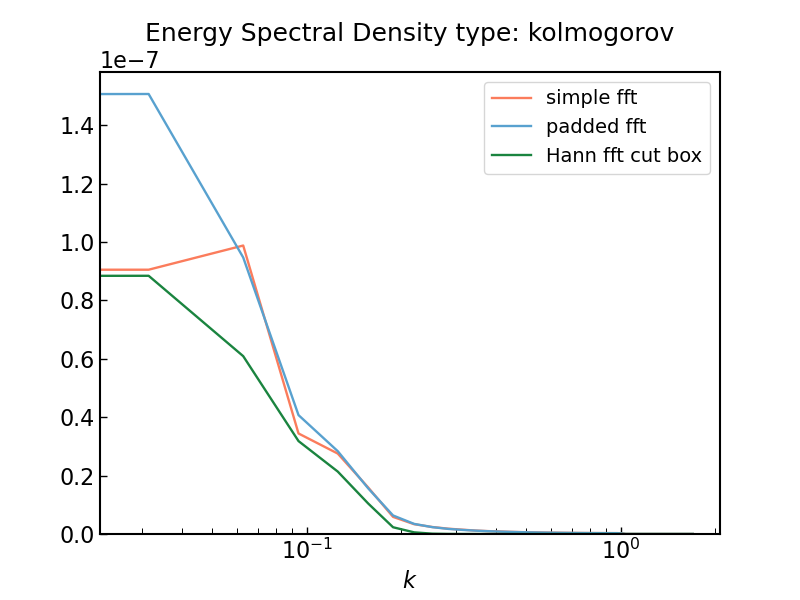

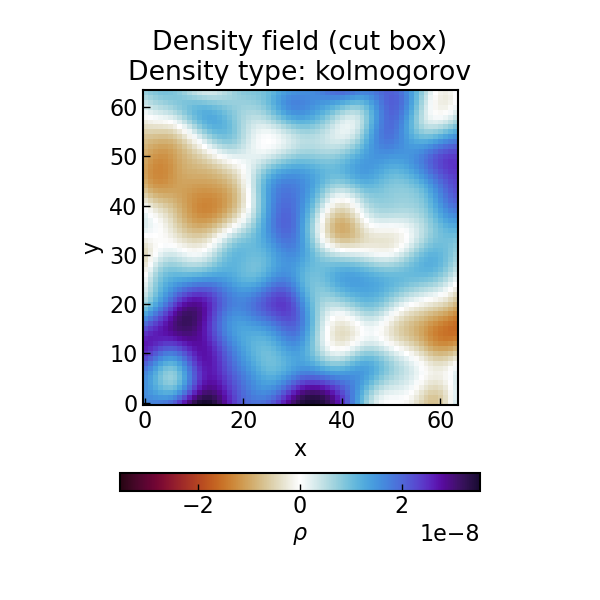

In [8]:
compute_make_plot(test_type='kolmogorov')

energy (real space) = 1.5259e-11
energy (fourier space) = 1.5259e-11
energy (real space) = 1.5259e-11
energy (fourier space) = 1.5259e-11
energy (real space) = 1.5259e-11
energy (fourier space) = 1.5257e-11


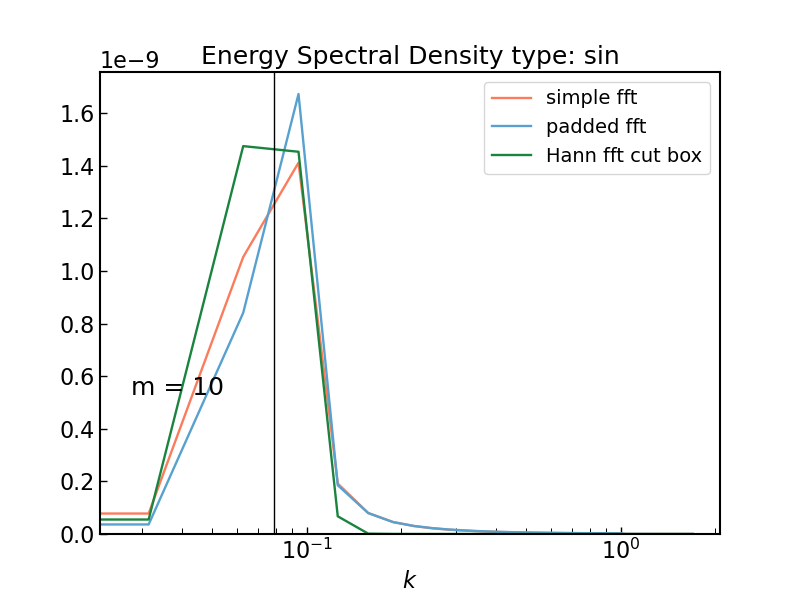

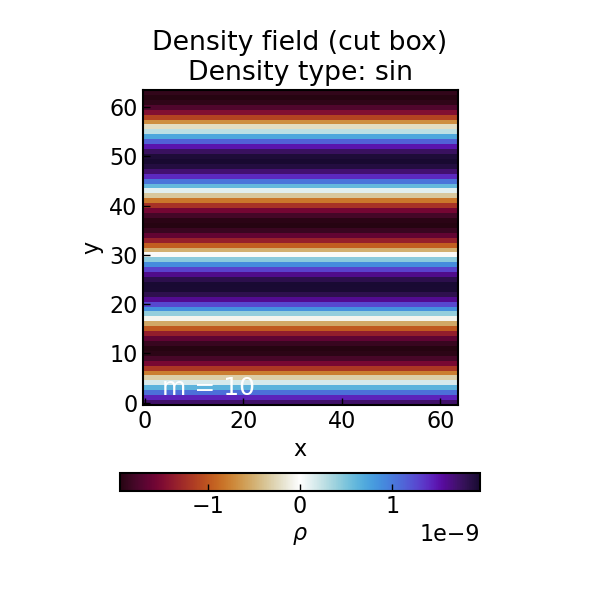

In [9]:
compute_make_plot(test_type='sin',m_mode=10)

energy (real space) = 1.9794e-11
energy (fourier space) = 1.9794e-11
energy (real space) = 1.9794e-11
energy (fourier space) = 1.9794e-11
energy (real space) = 1.9794e-11
energy (fourier space) = 2.1729e-11


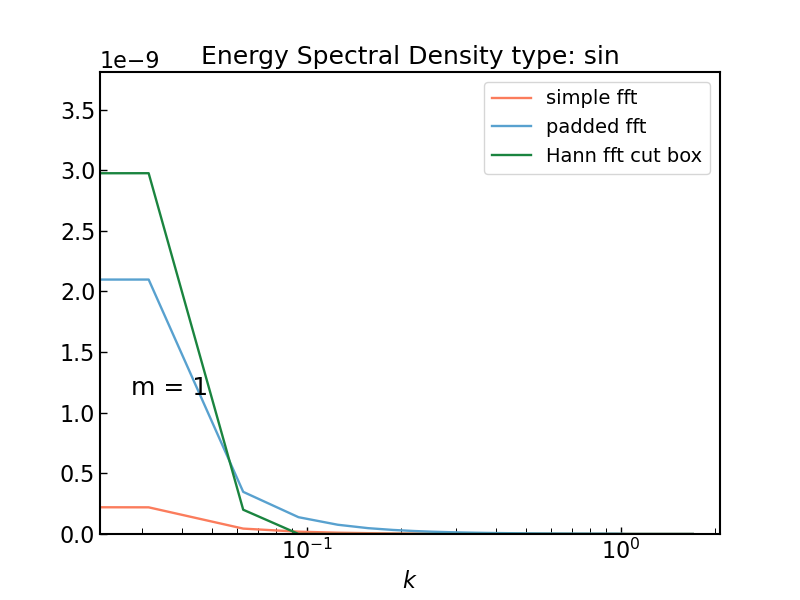

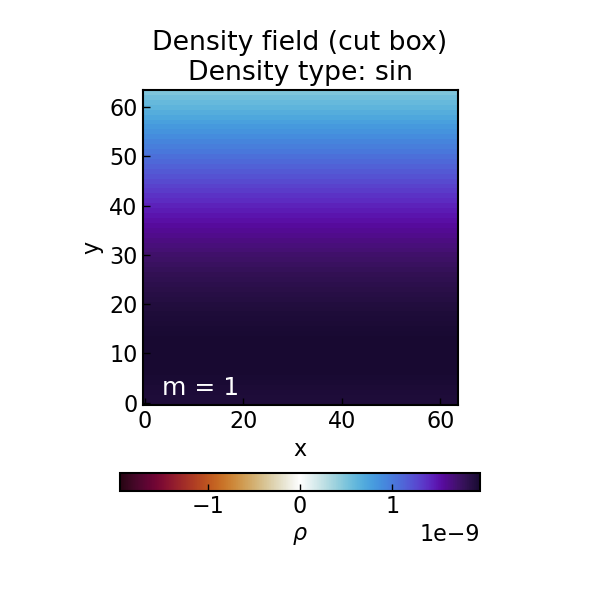

In [10]:
compute_make_plot(test_type='sin',m_mode=1)

energy (real space) = 3.1114e-02
energy (fourier space) = 3.1114e-02
energy (real space) = 3.1114e-02
energy (fourier space) = 3.1114e-02
energy (real space) = 3.1114e-02
energy (fourier space) = 9.2136e-02


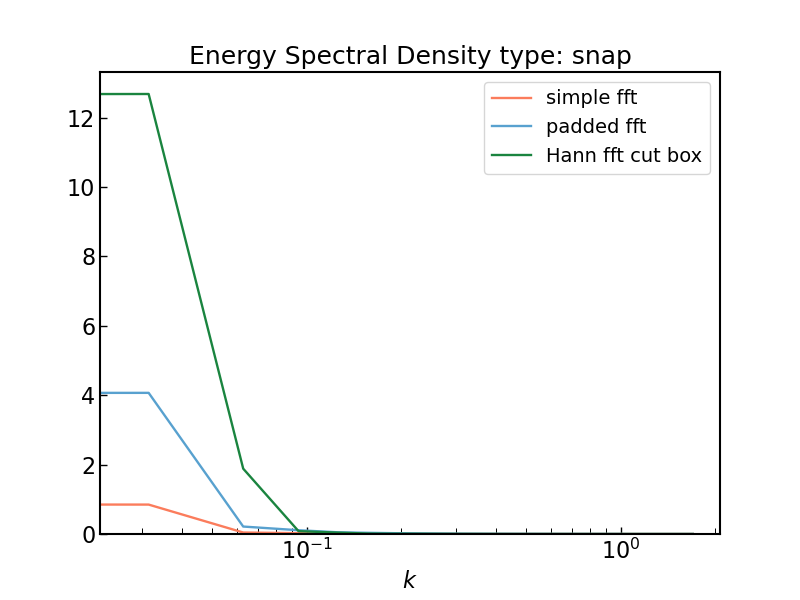

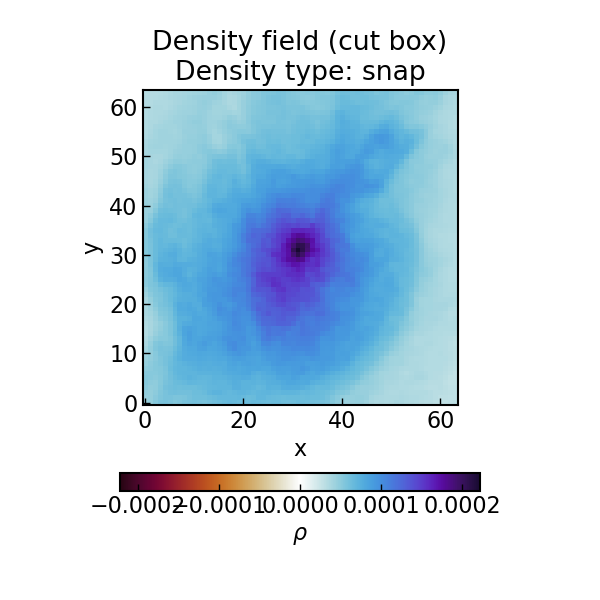

In [11]:
compute_make_plot(test_type='snap')